# Wine Quality Prediction Using Decision Tree, Random Forest, and Gradient Boosting

**Team:** M. CharanTej Reddy (2520030422) and Chandrakanth Reddy (2520030290)  
**Guide:** Dr. Jyothsna Datti  
**Course:** Machine Learning, A.Y. 2026-27

This notebook follows the supplied project abstract and presentation. It predicts a binary wine-quality class from 11 physicochemical features and compares Decision Tree, Random Forest, and Gradient Boosting using Accuracy, Precision, Recall, and F1-Score.


In [1]:
# 1. Imports and configuration
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

DATA_PATH = Path("../data/winequality-red.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("data/winequality-red.csv")

RANDOM_STATE = 42
TEST_SIZE = 0.20

FEATURES = [
    "fixed acidity", "volatile acidity", "citric acid", "residual sugar",
    "chlorides", "free sulfur dioxide", "total sulfur dioxide",
    "density", "pH", "sulphates", "alcohol"
]


## 2. Load the supplied Wine Quality dataset

In [2]:
df_raw = pd.read_csv(DATA_PATH)
print("Raw shape:", df_raw.shape)
display(df_raw.head())
print("\nColumns:", df_raw.columns.tolist())


Raw shape: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5



Columns: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']


In [3]:
# Check data quality
print("Missing values:", int(df_raw.isna().sum().sum()))
print("Duplicate rows:", int(df_raw.duplicated().sum()))
print("\nData types:")
display(df_raw.dtypes)


Missing values: 0
Duplicate rows: 240

Data types:


fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

### Preprocessing

The supplied presentation specifies duplicate removal, StandardScaler, and an 80/20 stratified split. The original quality score is converted to a binary target using the presentation's threshold:

- `0` = Standard Quality (`quality < 6.5`)
- `1` = Premium Quality (`quality >= 6.5`)


In [4]:
df = df_raw.drop_duplicates().reset_index(drop=True)

X = df[FEATURES]
y = (df["quality"] >= 6.5).astype(int)

print("Rows after duplicate removal:", len(df))
print("Duplicates removed:", len(df_raw) - len(df))
print("\nTarget distribution:")
display(y.value_counts().rename(index={0:"Standard Quality",1:"Premium Quality"}))


Rows after duplicate removal: 1359
Duplicates removed: 240

Target distribution:


quality
Standard Quality    1175
Premium Quality      184
Name: count, dtype: int64

## 3. Exploratory Data Analysis

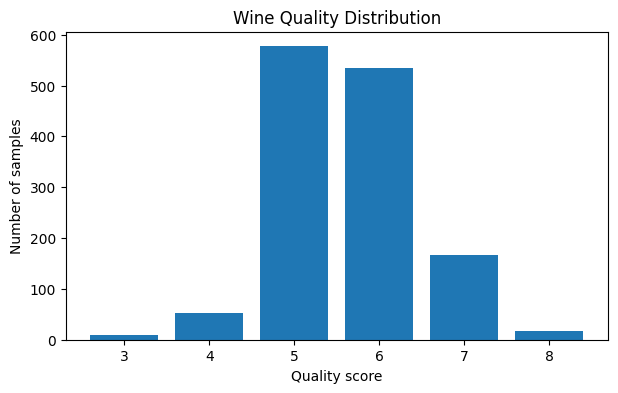

In [5]:
# Original quality distribution
quality_counts = df["quality"].value_counts().sort_index()
plt.figure(figsize=(7,4))
plt.bar(quality_counts.index.astype(str), quality_counts.values)
plt.title("Wine Quality Distribution")
plt.xlabel("Quality score")
plt.ylabel("Number of samples")
plt.show()


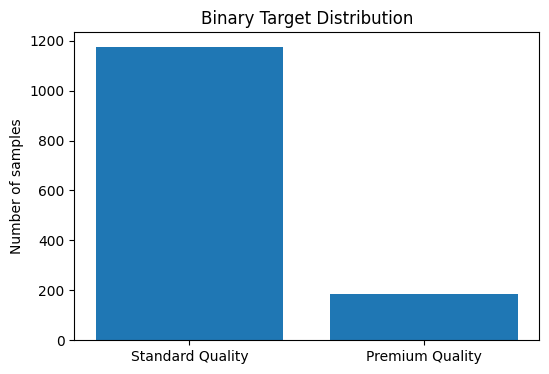

In [6]:
# Binary class distribution
class_counts = y.value_counts().sort_index()
plt.figure(figsize=(6,4))
plt.bar(["Standard Quality", "Premium Quality"], class_counts.values)
plt.title("Binary Target Distribution")
plt.ylabel("Number of samples")
plt.show()


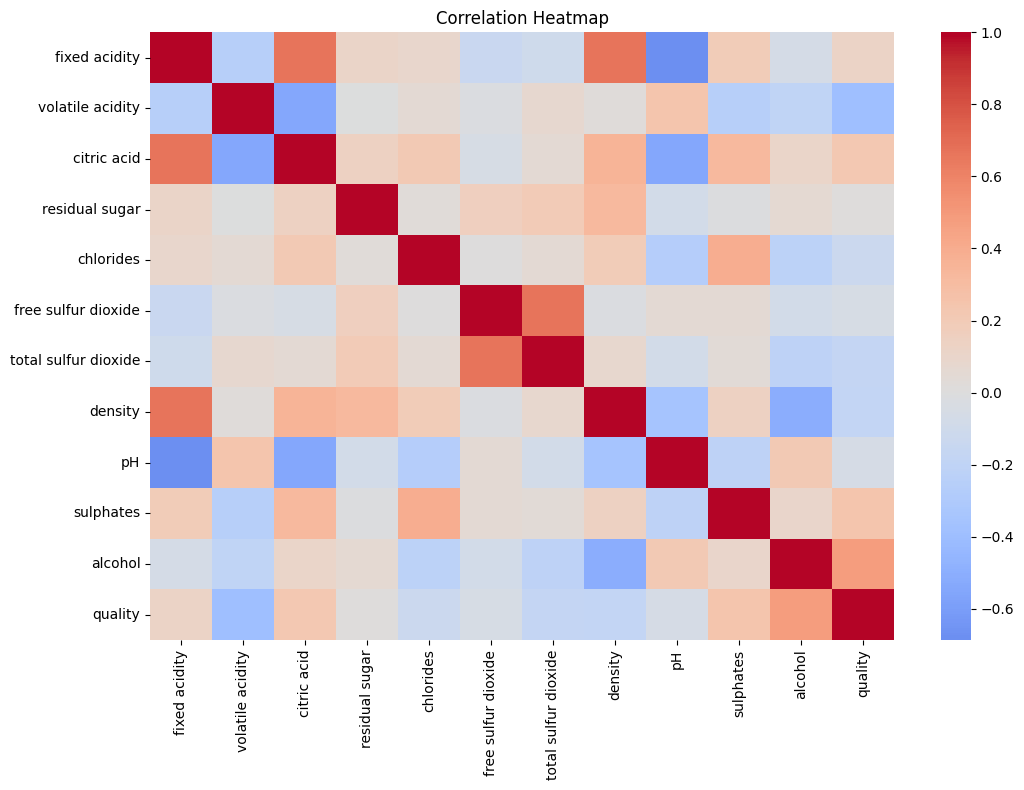

In [7]:
# Correlation heatmap
plt.figure(figsize=(11,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


In [8]:
# Summary statistics
display(df.describe().T.round(3))


,count,mean,std,min,25%,50%,75%,max
fixed acidity,1359.0,8.311,1.737,4.600,7.100,7.900,9.200,15.900
volatile acidity,1359.0,0.529,0.183,0.120,0.390,0.520,0.640,1.580
citric acid,1359.0,0.272,0.196,0.000,0.090,0.260,0.430,1.000
residual sugar,1359.0,2.523,1.352,0.900,1.900,2.200,2.600,15.500
chlorides,1359.0,0.088,0.049,0.012,0.070,0.079,0.091,0.611
free sulfur dioxide,1359.0,15.893,10.447,1.000,7.000,14.000,21.000,72.000
total sulfur dioxide,1359.0,46.826,33.409,6.000,22.000,38.000,63.000,289.000
density,1359.0,0.997,0.002,0.990,0.996,0.997,0.998,1.004
pH,1359.0,3.310,0.155,2.740,3.210,3.310,3.400,4.010
sulphates,1359.0,0.659,0.171,0.330,0.550,0.620,0.730,2.000


## 4. Train-Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Training positive rate:", round(y_train.mean(), 4))
print("Testing positive rate:", round(y_test.mean(), 4))


Training samples: 1087
Testing samples: 272
Training positive rate: 0.1352
Testing positive rate: 0.136


## 5. Define the three models

In [10]:
models = {
    "Decision Tree": Pipeline([
        ("scaler", StandardScaler()),
        ("model", DecisionTreeClassifier(
            criterion="gini",
            max_depth=6,
            min_samples_split=5,
            random_state=RANDOM_STATE
        ))
    ]),
    "Random Forest": Pipeline([
        ("scaler", StandardScaler()),
        ("model", RandomForestClassifier(
            n_estimators=100,
            max_features="sqrt",
            oob_score=True,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),
    "Gradient Boosting": Pipeline([
        ("scaler", StandardScaler()),
        ("model", GradientBoostingClassifier(
            n_estimators=150,
            learning_rate=0.1,
            subsample=0.8,
            random_state=RANDOM_STATE
        ))
    ])
}


## 6. Train and evaluate

In [11]:
results = []
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    predictions[name] = pred

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1-Score": f1_score(y_test, pred, zero_division=0)
    })

results_df = pd.DataFrame(results)
display(results_df.round(4))


,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.8787,0.5833,0.3784,0.4590
1,Random Forest,0.8971,0.7368,0.3784,0.5000
2,Gradient Boosting,0.8934,0.6818,0.4054,0.5085


## 7. Classification reports and confusion matrices

Decision Tree
                  precision    recall  f1-score   support

Standard Quality       0.91      0.96      0.93       235
 Premium Quality       0.58      0.38      0.46        37

        accuracy                           0.88       272
       macro avg       0.75      0.67      0.70       272
    weighted avg       0.86      0.88      0.87       272



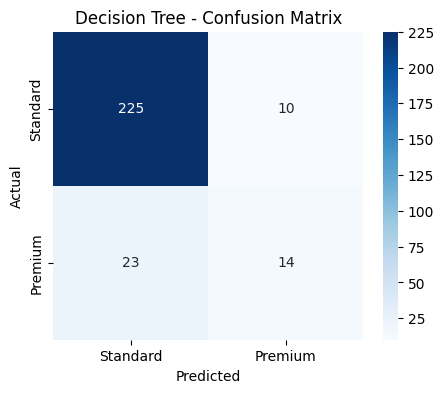

Random Forest
                  precision    recall  f1-score   support

Standard Quality       0.91      0.98      0.94       235
 Premium Quality       0.74      0.38      0.50        37

        accuracy                           0.90       272
       macro avg       0.82      0.68      0.72       272
    weighted avg       0.89      0.90      0.88       272



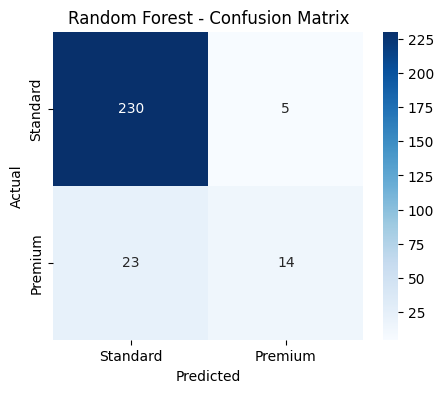

Gradient Boosting
                  precision    recall  f1-score   support

Standard Quality       0.91      0.97      0.94       235
 Premium Quality       0.68      0.41      0.51        37

        accuracy                           0.89       272
       macro avg       0.80      0.69      0.72       272
    weighted avg       0.88      0.89      0.88       272



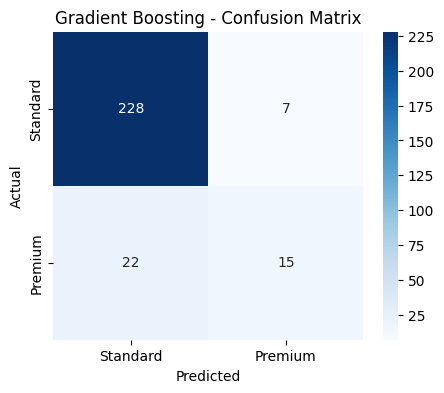

In [12]:
for name, pred in predictions.items():
    print("=" * 70)
    print(name)
    print(classification_report(
        y_test, pred,
        target_names=["Standard Quality", "Premium Quality"],
        zero_division=0
    ))

    cm = confusion_matrix(y_test, pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["Standard", "Premium"],
        yticklabels=["Standard", "Premium"]
    )
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


## 8. Feature importance


 Decision Tree


,Feature,Importance
10,alcohol,0.328995
9,sulphates,0.148938
5,free sulfur dioxide,0.110819
8,pH,0.097816
1,volatile acidity,0.076615
3,residual sugar,0.074787
6,total sulfur dioxide,0.062340
2,citric acid,0.030490
4,chlorides,0.027477
0,fixed acidity,0.024791



 Random Forest


,Feature,Importance
10,alcohol,0.171173
9,sulphates,0.127573
1,volatile acidity,0.100928
7,density,0.089219
2,citric acid,0.080875
6,total sulfur dioxide,0.080352
0,fixed acidity,0.078449
8,pH,0.073168
4,chlorides,0.070480
5,free sulfur dioxide,0.068652



 Gradient Boosting


,Feature,Importance
10,alcohol,0.258974
9,sulphates,0.161065
1,volatile acidity,0.100363
6,total sulfur dioxide,0.079935
0,fixed acidity,0.077786
5,free sulfur dioxide,0.062050
2,citric acid,0.061670
8,pH,0.058885
7,density,0.054649
4,chlorides,0.045146


<Figure size 1000x700 with 0 Axes>

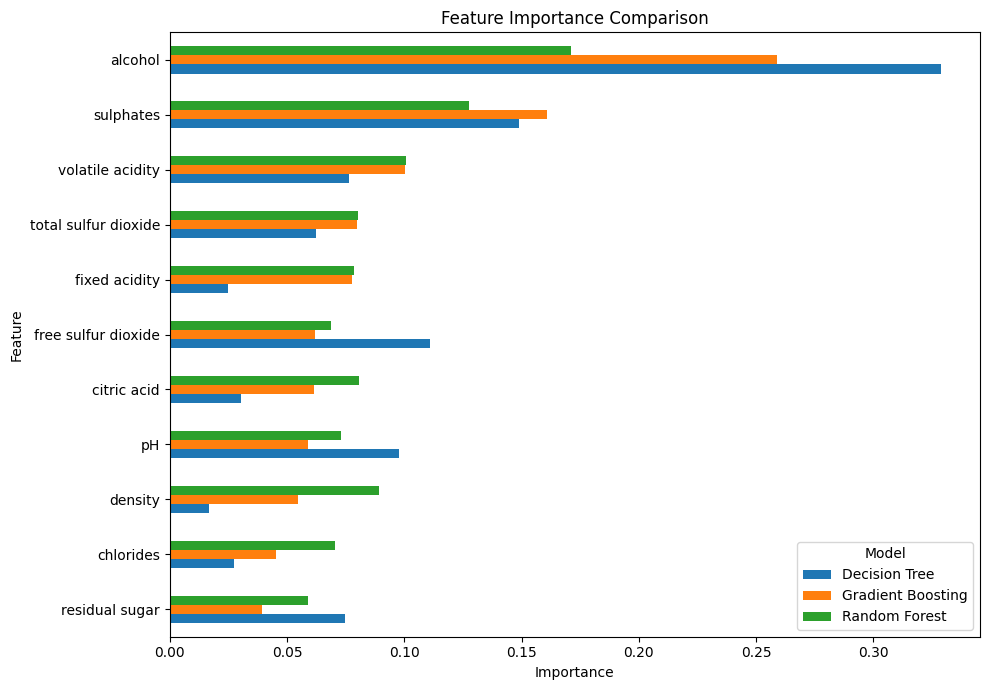

In [13]:
importance_frames = []

for name, pipe in models.items():
    estimator = pipe.named_steps["model"]
    imp = pd.DataFrame({
        "Feature": FEATURES,
        "Importance": estimator.feature_importances_
    }).sort_values("Importance", ascending=False)

    print("\n", name)
    display(imp)

    temp = imp.copy()
    temp["Model"] = name
    importance_frames.append(temp)

all_importance = pd.concat(importance_frames, ignore_index=True)

pivot = all_importance.pivot(
    index="Feature", columns="Model", values="Importance"
)

plt.figure(figsize=(10,7))
pivot.sort_values(by="Gradient Boosting", ascending=True).plot(kind="barh", figsize=(10,7))
plt.title("Feature Importance Comparison")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


## 9. Example prediction

The following example uses the first test sample and shows the prediction made by all three models.


In [14]:
sample = X_test.iloc[[0]]
print("Input sample:")
display(sample)

for name, model in models.items():
    pred = int(model.predict(sample)[0])
    label = "Premium Quality" if pred == 1 else "Standard Quality"
    print(f"{name}: {label}")


Input sample:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
1117,8.0,1.18,0.21,1.9,0.083,14.0,41.0,0.99532,3.34,0.47,10.5


Decision Tree: Standard Quality


Random Forest: Standard Quality
Gradient Boosting: Standard Quality


## 10. Conclusion

The notebook completes the requested workflow: data cleaning, EDA, binary target creation, stratified train-test splitting, training of Decision Tree/Random Forest/Gradient Boosting, evaluation using Accuracy/Precision/Recall/F1, confusion matrices, and feature importance.

**Important:** the supplied presentation contains headline performance numbers that differ from the reproducible results generated from the supplied CSV after duplicate removal. This notebook reports the values it actually calculates rather than hard-coding presentation values.
